In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent

pnl_file = (
    PROJECT_ROOT
    / "reports"
    / "daily_pnl.csv"
)

daily_pnl = pd.read_csv(
    pnl_file,
    parse_dates=["date"]
)

daily_pnl.head()

,date,portfolio_value,daily_pnl
0,2020-01-02,6.927691e+06,NaN
1,2020-01-03,6.969933e+06,42242.796941
2,2020-01-06,6.960841e+06,-9092.279519
3,2020-01-07,6.954212e+06,-6628.897992
4,2020-01-08,6.919158e+06,-35053.846395


In [2]:
daily_pnl.shape

(1495, 3)

In [3]:
daily_pnl.columns.tolist()

['date', 'portfolio_value', 'daily_pnl']

In [4]:
daily_pnl["daily_pnl"].isna().sum()

np.int64(1)

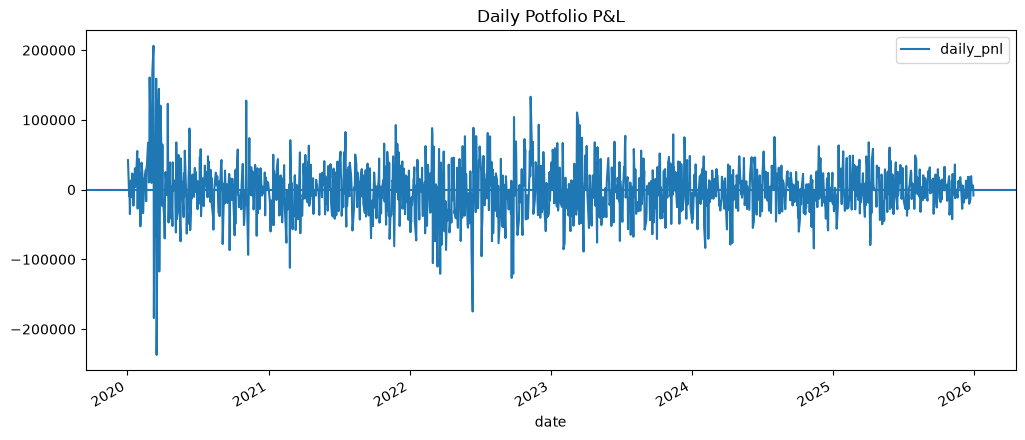

In [5]:
import matplotlib.pyplot as plt
daily_pnl.plot(x="date",y="daily_pnl",figsize=(12,5),title="Daily Potfolio P&L")
plt.axhline(0)
plt.show()

In [6]:
daily_pnl["date"] = pd.to_datetime(daily_pnl["date"])

daily_pnl["daily_pnl"] = pd.to_numeric(
    daily_pnl["daily_pnl"],
    errors="coerce"
)

daily_pnl.dtypes

date               datetime64[us]
portfolio_value           float64
daily_pnl                 float64
dtype: object

In [7]:
positive_days = (daily_pnl["daily_pnl"] > 0).sum()
negative_days = (daily_pnl["daily_pnl"] < 0).sum()
zero_days = (daily_pnl["daily_pnl"] == 0).sum()

print("Positive days:", positive_days)
print("Negative days:", negative_days)
print("Zero days:", zero_days)

Positive days: 744
Negative days: 750
Zero days: 0


In [8]:
print("Mean P&L:", daily_pnl["daily_pnl"].mean())
print("Std P&L:", daily_pnl["daily_pnl"].std())
print("Minimum P&L:", daily_pnl["daily_pnl"].min())
print("Maximum P&L:", daily_pnl["daily_pnl"].max())

Mean P&L: -967.5122456950593
Std P&L: 36456.94912751187
Minimum P&L: -237048.6794262268
Maximum P&L: 206248.32202713192
